# First-token gap vs full-answer delta

**The question.** For tulu, mean `delta` (eval.py's length-normalised full-answer
log-prob gap, positive = favours the CONTEXT answer) barely moves across the decline:
peak `+1.177` -> trough `+1.093`, with only 54% of items moving toward the parametric
answer -- essentially chance. Yet R_ctx over those same checkpoints drops 0.955 -> 0.776.
So at the trough the model still *scores* the contextual answer higher, but its greedy
output increasingly *states* the parametric one.

**The hypothesis.** `delta` averages over all answer tokens, but greedy generation
commits at the **first token**. An answer can win on average and lose at token 1. If the
inversion lives in first-token commitment, then the first-token gap should track the
R_ctx trajectory (drop peak->trough, recover) while `delta` does not.

**The measurement.** For every item that passed the Layer-0 filter, at each phase
checkpoint, record both quantities on the *same* prompt:

- `delta`      -- `eval.py`'s own `method_logprob` (unchanged, reused directly)
- `first_gap`  -- `logit(cf_first_token) - logit(par_first_token)` at the last prompt
                  position, same sign convention

No judge, no API, forward passes only. ~400 items x 5 checkpoints.

### Repo + Drive + checkpoints

In [3]:
import os

GITHUB_REPO_URL = "https://github.com/GIRIAYUSH/context-parametric-inversion-research.git"
REPO_DIR = "/content/context-parametric-inversion-research"
BRANCH = "dev"

if not os.path.isdir(REPO_DIR):
    !git clone --branch {BRANCH} {GITHUB_REPO_URL} {REPO_DIR}

%cd {REPO_DIR}
!git fetch origin {BRANCH} && git reset --hard origin/{BRANCH}
!git log --oneline -3

/content/context-parametric-inversion-research
From https://github.com/GIRIAYUSH/context-parametric-inversion-research
 * branch            dev        -> FETCH_HEAD
HEAD is now at 1da5e71 first_token_gap: measure both metrics on both prompts (2x2)
1da5e71 (HEAD -> dev, origin/dev) first_token_gap: measure both metrics on both prompts (2x2)
10434b5 CPI research: SFT pipeline, conflict-eval harness, and mechanistic analysis
8b0d057 (origin/master, origin/HEAD) apply_patches.py: never downgrade a resolved final_label to AMBIG


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Staging Checkpoints from Drive

In [5]:
import yaml, shutil

cfg = yaml.safe_load(open("src/mechanistic-analysis/checkpoints.yaml"))
STAGE_DIR = "/content/staged_checkpoints"

for run, run_cfg in cfg["runs"].items():
    for phase, ckpt_name in run_cfg["phases"].items():
        if ckpt_name is None:
            continue
        dst = os.path.join(STAGE_DIR, run, ckpt_name)
        if os.path.isdir(dst):
            print("already staged:", run, ckpt_name)
            continue
        print("staging", run, phase, ckpt_name)
        shutil.copytree(os.path.join(run_cfg["drive_checkpoint_dir"], ckpt_name), dst)

def phase_path(run, phase):
    c = cfg["runs"][run]["phases"][phase]
    return None if c is None else os.path.join(STAGE_DIR, run, c)

already staged: alpaca checkpoint-100
already staged: alpaca checkpoint-800
already staged: tulu checkpoint-500
already staged: tulu checkpoint-3150
already staged: tulu checkpoint-5000


### Model + tokenizer

In [6]:
from huggingface_hub import login
from google.colab import userdata

# Read from Colab Secrets (key icon in the left sidebar) -- add a secret
# named HF_TOKEN. Never paste the token literal here: it gets committed,
# GitHub push protection blocks the push, and the token has to be rotated.
HF_TOKEN = ""
login(token=HF_TOKEN)

In [7]:
!pip install -q peft accelerate

In [8]:
import json, torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

tok = AutoTokenizer.from_pretrained(cfg["base_model"] , token = HF_TOKEN)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    cfg["base_model"], token = HF_TOKEN,torch_dtype=torch.bfloat16, device_map="cuda").eval()
print("loaded", cfg["base_model"])

def model_for_phase(ckpt_path):
    """Swaps the LoRA adapter in place; base weights load once."""
    global base_model
    if isinstance(base_model, PeftModel):
        base_model = base_model.unload()
    if ckpt_path is not None:
        base_model = PeftModel.from_pretrained(base_model, ckpt_path).eval()
    return base_model

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/188 [00:00<?, ?B/s]

loaded meta-llama/Llama-2-7b-hf


In [9]:
# Llama-2's tokenizer ships no chat template, so eval.py's use_ct=True would silently
# fall back to a raw string the model was never tuned on. Set the tulu format (run_sft.py's
# _concat_messages) and verify byte-for-byte against a prompt the original eval stored.
TULU_CHAT_TEMPLATE = (
    "{{ bos_token }} "          # trailing space: reproduces the sentencepiece prefix
    "{% for message in messages %}"
    "{% if message['role'] == 'user' %}"
    "{{ '<|user|>\n' + message['content'].strip() + '\n' }}"
    "{% elif message['role'] == 'assistant' %}"
    "{{ '<|assistant|>\n' + message['content'].strip() + eos_token + '\n' }}"
    "{% endif %}"
    "{% endfor %}"
    "{% if add_generation_prompt %}{{ '<|assistant|>\n' }}{% endif %}"
)
tok.chat_template = TULU_CHAT_TEMPLATE

import sys
sys.path.insert(0, "src/evaluation")
import eval as cpi_eval

REF = "results/cpi-results/tulu-results/checkpoint_step3150_metrics.json"
ref_row = next(r for r in json.load(open(REF, encoding="utf-8"))["per_item"]
               if r["item_id"] == "cap_0013")
ours = tok.decode(cpi_eval.build_score_prompt_ids(
    tok, ref_row["question"], ref_row["context"], True), skip_special_tokens=False)

assert ours == ref_row["score_prompt_text"], f"PROMPT MISMATCH\nours  : {ours!r}\nstored: {ref_row['score_prompt_text']!r}"
print("prompt verified -- byte-identical to the recorded eval")

prompt verified -- byte-identical to the recorded eval


### Items and the reference results

`passed` (the Layer-0 filter) and the stored `delta` come from the committed per-checkpoint results, so we measure exactly the item set the original trajectory used -- and get a free correctness check by comparing our recomputed `delta` against the stored one.

In [10]:
items = {it["item_id"]: it for it in cpi_eval.load_items("dataset/conflict_eval_unified.json")}

# (run, phase, step, path to the committed result for that step)
PHASES = [
    ("alpaca", "peak",     100,  "results/cpi-results/alpaca-results/checkpoint_step100_metrics.json"),
    ("alpaca", "trough",   800,  "results/cpi-results/alpaca-results/checkpoint_step800_metrics.json"),
    ("tulu",   "peak",     500,  "results/cpi-results/tulu-results/checkpoint_step500_metrics.json"),
    ("tulu",   "trough",   3150, "results/cpi-results/tulu-results/checkpoint_step3150_metrics.json"),
    ("tulu",   "recovery", 5000, "results/cpi-results/tulu-results/checkpoint_step5000_metrics.json"),
]

def reference(path):
    """{item_id: stored delta} for items that passed the Layer-0 filter."""
    rows = json.load(open(path, encoding="utf-8"))["per_item"]
    return {r["item_id"]: r["logprob"]["delta"] for r in rows
            if r.get("passed") and r.get("logprob") and "delta" in r["logprob"]}

for run, phase, step, path in PHASES:
    print(f"{run:7} {phase:9} step{step:<5} passed={len(reference(path))}")

Loaded 417 total | dropped 5 flagged item(s) | 412 usable
alpaca  peak      step100   passed=401
alpaca  trough    step800   passed=399
tulu    peak      step500   passed=399
tulu    trough    step3150  passed=397
tulu    recovery  step5000  passed=400


### Measure

In [12]:
!pip uninstall -q -y torchao

In [13]:
@torch.no_grad()
def gap_and_argmax(model, prompt_ids, par_tok, cf_tok):
    """Returns (first-token gap, greedy first token).

    gap = logit(cf first token) - logit(par first token) at the last prompt
    position -- same sign convention as eval.py's delta, so > 0 favours CONTEXT.
    The argmax token tells us what the model would actually emit first, which
    matters on the gen prompt: with no prefill it sometimes emits a preamble
    ("Answer:") rather than the answer, in which case the gap is measuring
    formatting rather than the answer choice."""
    logits = model(prompt_ids.unsqueeze(0).to(model.device)).logits[0, -1, :]
    gap = (logits[cf_tok] - logits[par_tok]).item()
    return gap, tok.decode(logits.argmax().item())


def first_tok(text):
    return tok(" " + text.strip(), add_special_tokens=False).input_ids[0]


# The 2x2. delta/first_gap are measured on the SCORE prompt (prefill
# "The answer is:") but every label comes from free generation on the GEN prompt
# (no prefill). Those differ in two ways at once -- the prompt AND the procedure
# (teacher-forced scoring of fixed candidates vs free decoding). Measuring both
# metrics on BOTH prompts isolates the prompt while holding the procedure fixed.
PROMPTS = {"score": cpi_eval.build_score_prompt_ids,
           "gen":   cpi_eval.build_gen_prompt_ids}

rows = []
for run, phase, step, path in PHASES:
    stored = reference(path)
    model = model_for_phase(phase_path(run, phase))
    print(f"measuring {run}/{phase} ({len(stored)} items) ...", flush=True)

    for iid, stored_delta in stored.items():
        it = items[iid]
        par, cf = it["parametric_answer"], it["counterfactual_answer"]
        ptok, ctok = first_tok(par), first_tok(cf)

        rec = {"run": run, "phase": phase, "step": step, "item_id": iid,
               "stored_delta": stored_delta}
        for tag, build in PROMPTS.items():
            pid = build(tok, it["question"], it["context"], True)
            rec[f"delta_{tag}"] = cpi_eval.method_logprob(model, tok, pid, par, cf)["delta"]
            g, first = gap_and_argmax(model, pid, ptok, ctok)
            rec[f"first_gap_{tag}"] = g
            rec[f"first_emitted_{tag}"] = first
        rows.append(rec)

json.dump(rows, open("src/mechanistic-analysis/first_token_gap.json", "w"), indent=2)
print(f"\nwrote src/mechanistic-analysis/first_token_gap.json ({len(rows)} rows)")

measuring alpaca/peak (401 items) ...
measuring alpaca/trough (399 items) ...
measuring tulu/peak (399 items) ...
measuring tulu/trough (397 items) ...
measuring tulu/recovery (400 items) ...

wrote src/mechanistic-analysis/first_token_gap.json (1996 rows)


### Check we reproduce the original measurement (Sanity Check)

In [15]:
import numpy as np

for run, phase, step, _ in PHASES:
    sub = [r for r in rows if r["run"] == run and r["phase"] == phase]
    a = np.array([r["delta_score"] for r in sub])
    b = np.array([r["stored_delta"] for r in sub])
    r_ = np.corrcoef(a, b)[0, 1]
    print(f"{run:7} {phase:9} n={len(sub):4}  corr(ours, stored)={r_:.3f}  "
          f"mean offset={float((a-b).mean()):+.3f}")
print("\ncorr > ~0.95 = we reproduce the recorded measurement up to the known "
      "double-space fix.\ncorr < ~0.9 = investigate before reading anything below.")

alpaca  peak      n= 401  corr(ours, stored)=0.892  mean offset=+0.092
alpaca  trough    n= 399  corr(ours, stored)=0.883  mean offset=-0.087
tulu    peak      n= 399  corr(ours, stored)=0.846  mean offset=+0.254
tulu    trough    n= 397  corr(ours, stored)=0.875  mean offset=+0.352
tulu    recovery  n= 400  corr(ours, stored)=0.862  mean offset=+0.537

corr > ~0.95 = we reproduce the recorded measurement up to the known double-space fix.
corr < ~0.9 = investigate before reading anything below.


### Result: does first_gap track R_ctx where delta doesn't?

In [16]:
R_CTX = {("alpaca", "peak"): 0.890, ("alpaca", "trough"): 0.789,
         ("tulu", "peak"): 0.955, ("tulu", "trough"): 0.776, ("tulu", "recovery"): 0.902}

M = ["delta_score", "delta_gen", "first_gap_score", "first_gap_gen"]

print("MEANS per checkpoint (> 0 favours CONTEXT)")
print(f"{'run':8}{'phase':10}{'n':>5}" + "".join(f"{m:>17}" for m in M) + f"{'R_ctx':>8}")
summary = {}
for run, phase, step, _ in PHASES:
    sub = [r for r in rows if r["run"] == run and r["phase"] == phase]
    vals = {m: float(np.mean([r[m] for r in sub])) for m in M}
    summary[(run, phase)] = vals
    print(f"{run:8}{phase:10}{len(sub):5}" + "".join(f"{vals[m]:17.3f}" for m in M)
          + f"{R_CTX[(run, phase)]:8.3f}")

print("\nPAIRED per-item shifts across each leg (toward PAR = the CPI direction)")
for run, ep, lp in [("alpaca", "peak", "trough"),
                    ("tulu", "peak", "trough"), ("tulu", "trough", "recovery")]:
    e = {r["item_id"]: r for r in rows if r["run"] == run and r["phase"] == ep}
    l = {r["item_id"]: r for r in rows if r["run"] == run and r["phase"] == lp}
    common = sorted(set(e) & set(l))
    dR = R_CTX[(run, lp)] - R_CTX[(run, ep)]
    print(f"\n  {run} {ep}->{lp}  n={len(common)}   R_ctx change = {dR:+.3f}")
    for m in M:
        d = np.array([l[i][m] - e[i][m] for i in common])
        print(f"     {m:16} mean={d.mean():+7.3f}   toward PAR: {(d<0).sum():4}/{len(d)} ({(d<0).mean():.0%})")

# is first_gap measuring the answer, or formatting?
print("\nHow often is the greedy first token NOT a candidate answer's first token?")
for run, phase, step, _ in PHASES:
    sub = [r for r in rows if r["run"] == run and r["phase"] == phase]
    for tag in ("score", "gen"):
        it0 = [items[r["item_id"]] for r in sub]
        off = sum(1 for r, it in zip(sub, it0)
                  if r[f"first_emitted_{tag}"].strip() not in
                     (it["parametric_answer"].split()[0], it["counterfactual_answer"].split()[0]))
        print(f"  {run:7} {phase:9} {tag:6} {off:4}/{len(sub)} ({off/len(sub):.0%}) emit something else first")

MEANS per checkpoint (> 0 favours CONTEXT)
run     phase         n      delta_score        delta_gen  first_gap_score    first_gap_gen   R_ctx
alpaca  peak        401            0.940            1.129            1.820            2.212   0.890
alpaca  trough      399            0.593            0.782            1.150            1.555   0.789
tulu    peak        399            1.441            1.223            3.243            2.943   0.955
tulu    trough      397            1.445            1.218            3.640            2.946   0.776
tulu    recovery    400            2.081            1.930            5.090            4.641   0.902

PAIRED per-item shifts across each leg (toward PAR = the CPI direction)

  alpaca peak->trough  n=399   R_ctx change = -0.101
     delta_score      mean= -0.328   toward PAR:  289/399 (72%)
     delta_gen        mean= -0.313   toward PAR:  257/399 (64%)
     first_gap_score  mean= -0.643   toward PAR:  258/399 (65%)
     first_gap_gen    mean= -0.628   t

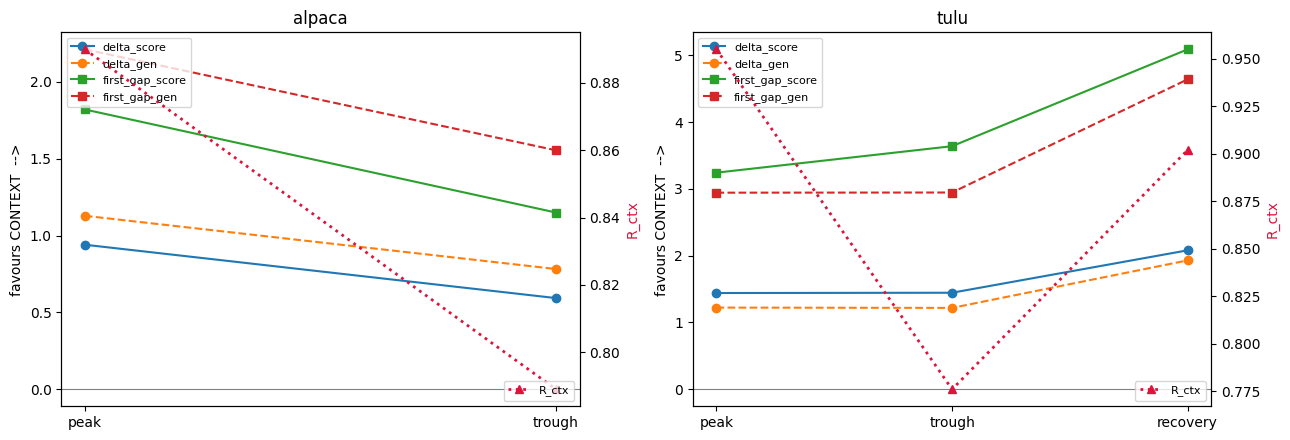

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, run in zip(axes, ["alpaca", "tulu"]):
    ph = [p for r, p, _, _ in PHASES if r == run]
    x = range(len(ph))
    for m, style in zip(M, ["o-", "o--", "s-", "s--"]):
        ax.plot(x, [summary[(run, p)][m] for p in ph], style, label=m)
    ax.set_xticks(list(x)); ax.set_xticklabels(ph)
    ax.axhline(0, color="gray", lw=0.8)
    ax.set_ylabel("favours CONTEXT  -->")
    ax2 = ax.twinx()
    ax2.plot(x, [R_CTX[(run, p)] for p in ph], "^:", color="crimson", lw=2, label="R_ctx")
    ax2.set_ylabel("R_ctx", color="crimson")
    ax.set_title(run); ax.legend(loc="upper left", fontsize=8); ax2.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("src/mechanistic-analysis/first_token_gap.png", dpi=150)
plt.show()

In [18]:
# ============================================================================
# DIAGNOSTIC: does our tokenizer reproduce the recorded eval's tokenization?
# No model required -- n_par/n_cf and token ids are pure tokenizer output.
# ============================================================================
import json

REF = "results/cpi-results/tulu-results/checkpoint_step3150_metrics.json"
stored = {r["item_id"]: r for r in json.load(open(REF, encoding="utf-8"))["per_item"]
          if r.get("logprob") and "n_par" in r["logprob"]}

# --- 1. answer token counts: ours vs recorded -------------------------------
bad = []
for iid, r in stored.items():
    op = len(tok(" " + r["parametric_answer"].strip(), add_special_tokens=False).input_ids)
    oc = len(tok(" " + r["counterfactual_answer"].strip(), add_special_tokens=False).input_ids)
    if (op, oc) != (r["logprob"]["n_par"], r["logprob"]["n_cf"]):
        bad.append((iid, r["parametric_answer"], op, r["logprob"]["n_par"],
                    r["counterfactual_answer"], oc, r["logprob"]["n_cf"]))

print(f"[1] answer-token-count mismatches: {len(bad)}/{len(stored)}")
for iid, par, op, sp, cf, oc, sc in bad[:8]:
    print(f"    {iid:10} par={par!r:24} ours={op} stored={sp}    cf={cf!r:24} ours={oc} stored={sc}")
if not bad:
    print("    -> answers tokenize identically; the difference is in the PROMPT")

# --- 2. what our prompt tokens actually look like ---------------------------
row = stored["cap_0013"]
ids = cpi_eval.build_score_prompt_ids(tok, row["question"], row["context"], True)
print(f"\n[2] our prompt: {len(ids)} tokens")
print("    first 10:", [tok.convert_ids_to_tokens(t) for t in ids[:10].tolist()])
print("    last 8  :", [tok.convert_ids_to_tokens(t) for t in ids[-8:].tolist()])
print("    decoded == stored score_prompt_text:",
      tok.decode(ids, skip_special_tokens=False) == row["score_prompt_text"])

# --- 3. same TEXT, two tokenizations? --------------------------------------
# build_score_prompt_ids tokenizes the template and the prefill SEPARATELY and
# concatenates them. Tokenizing the identical string in one go can give a
# different sequence at the join. If these disagree, our construction path is
# introducing a token-level difference that string comparison cannot see.
retok = tok(row["score_prompt_text"], return_tensors="pt",
            add_special_tokens=False).input_ids[0]
same = ids.tolist() == retok.tolist()
print(f"\n[3] ours={len(ids)} tokens vs re-tokenized-stored={len(retok)} tokens | identical: {same}")
if not same:
    for i, (a, b) in enumerate(zip(ids.tolist(), retok.tolist())):
        if a != b:
            print(f"    first difference at index {i}:")
            print(f"      ours   {a:6} {tok.convert_ids_to_tokens(a)!r}")
            print(f"      stored {b:6} {tok.convert_ids_to_tokens(b)!r}")
            print(f"      ours   context: {[tok.convert_ids_to_tokens(t) for t in ids[max(0,i-3):i+4].tolist()]}")
            print(f"      stored context: {[tok.convert_ids_to_tokens(t) for t in retok[max(0,i-3):i+4].tolist()]}")
            break

[1] answer-token-count mismatches: 400/412
    cap_0000   par='Kabul'                  ours=2 stored=3    cf='Herat'                  ours=2 stored=3
    cap_0001   par='Tirana'                 ours=2 stored=3    cf='Durrës'                 ours=4 stored=5
    cap_0002   par='Algiers'                ours=3 stored=4    cf='Oran'                   ours=2 stored=3
    cap_0003   par='Andorra la Vella'       ours=6 stored=7    cf='Encamp'                 ours=2 stored=3
    cap_0004   par='Luanda'                 ours=2 stored=3    cf='Huambo'                 ours=3 stored=4
    cap_0005   par="Saint John's"           ours=4 stored=5    cf='Falmouth'               ours=2 stored=3
    cap_0006   par='Buenos Aires'           ours=2 stored=3    cf='Córdoba'                ours=4 stored=5
    cap_0007   par='Yerevan'                ours=3 stored=4    cf='Gyumri'                 ours=3 stored=4

[2] our prompt: 121 tokens
    first 10: ['<s>', '▁<', '|', 'user', '|', '>', '<0x0A>', 'Read', '▁th

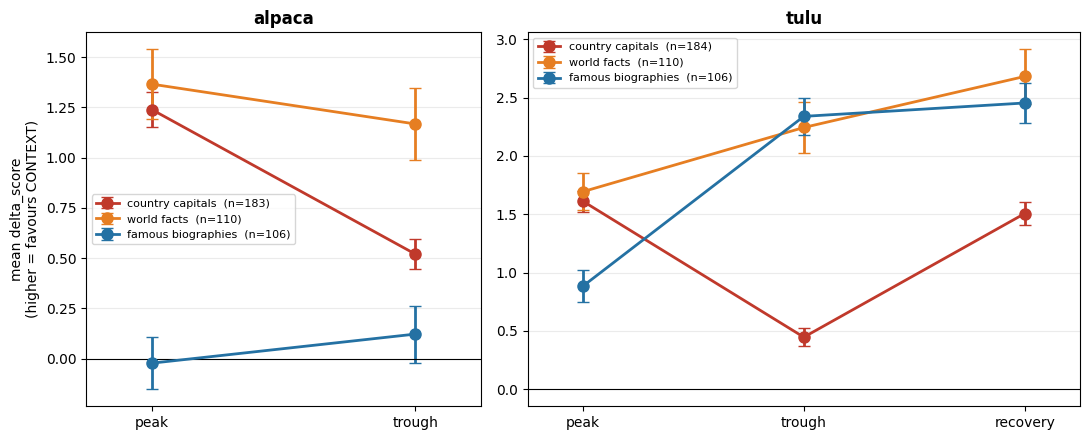

In [19]:
import json
import numpy as np
import matplotlib.pyplot as plt

rows = json.load(open("src/mechanistic-analysis/first_token_gap.json", encoding="utf-8"))
src = {it["item_id"]: it["source"]
       for it in json.load(open("dataset/conflict_eval_unified.json", encoding="utf-8"))}
for r in rows:
    r["source"] = src.get(r["item_id"], "?")

STRATA = ["country_capitals", "world_facts", "famous_biographies"]
COLOR = {"country_capitals": "#c0392b", "world_facts": "#e67e22",
         "famous_biographies": "#2471a3"}
PHASES = {"alpaca": ["peak", "trough"], "tulu": ["peak", "trough", "recovery"]}
METRIC = "delta_score"   # or delta_gen / first_gap_score / first_gap_gen

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5),
                         gridspec_kw={"width_ratios": [1, 1.4]})
for ax, (run, phases) in zip(axes, PHASES.items()):
    for s in STRATA:
        mean, sem, n0 = [], [], 0
        for p in phases:
            v = np.array([r[METRIC] for r in rows
                          if r["run"] == run and r["phase"] == p and r["source"] == s])
            mean.append(v.mean())
            sem.append(v.std(ddof=1) / np.sqrt(len(v)))
            n0 = len(v)
        ax.errorbar(range(len(phases)), mean, yerr=sem, marker="o", ms=8, lw=2,
                    capsize=4, color=COLOR[s],
                    label=f"{s.replace('_', ' ')}  (n={n0})")
    ax.set_xticks(range(len(phases)))
    ax.set_xticklabels(phases)
    ax.set_xlim(-0.25, len(phases) - 0.75)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(run, fontweight="bold")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(fontsize=8)
axes[0].set_ylabel(f"mean {METRIC}\n(higher = favours CONTEXT)")
plt.tight_layout()
plt.savefig("src/mechanistic-analysis/stratum_phases.png", dpi=150)
plt.show()

### Reading it

The label (and so R_ctx) comes from **free generation on the gen prompt**. The metrics
that did NOT move were measured on the **score prompt**. Those differ in two ways at
once -- prompt and procedure -- so the 2x2 above separates them:

- **`delta_gen` / `first_gap_gen` shift toward PAR across the tulu decline while the
  `_score` versions don't** -> the prefill `"The answer is:"` was masking the inversion.
  It is genuinely prompt-dependent, and that is a sharp, publishable claim.
- **Nothing shifts on either prompt** -> the inversion is not in the candidate-answer
  logits at all. It lives in free decoding itself, and the next place to look is the
  decoding trajectory (what the model commits to, and when), not candidate scores.
- **Watch the last block**: if the greedy first token is often *neither* candidate's
  first token (a preamble like "Answer:"), then `first_gap` on that prompt is partly
  measuring formatting, and a low shift there is weak evidence either way.

Recall what has to be explained: over the tulu decline the *label* moves hard
(CTX/PAR 381/17 -> 308/89, and the judge-free `ordered` classifier agrees, 0.950 ->
0.771) while `delta_score` is flat. Something has to account for that gap.

In [23]:
import json, yaml, torch, sys
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from huggingface_hub import login
from google.colab import userdata

login(token="")

sys.path.insert(0, "src/evaluation")
import eval as cpi_eval

cfg = yaml.safe_load(open("src/mechanistic-analysis/checkpoints.yaml"))

tok = AutoTokenizer.from_pretrained(cfg["base_model"])
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

# Llama-2 ships no chat template, so eval.py's use_ct=True would silently fall
# back to a raw string the model was never tuned on. Set the tulu format from
# run_sft.py's _concat_messages. The trailing space after bos_token reproduces
# sentencepiece's segment prefix -- without it the first content token differs.
tok.chat_template = (
    "{{ bos_token }} "
    "{% for message in messages %}"
    "{% if message['role'] == 'system' %}"
    "{{ '<|system|>\n' + message['content'].strip() + '\n' }}"
    "{% elif message['role'] == 'user' %}"
    "{{ '<|user|>\n' + message['content'].strip() + '\n' }}"
    "{% elif message['role'] == 'assistant' %}"
    "{{ '<|assistant|>\n' + message['content'].strip() + eos_token + '\n' }}"
    "{% endif %}"
    "{% endfor %}"
    "{% if add_generation_prompt %}{{ '<|assistant|>\n' }}{% endif %}"
)
USE_CT = True

# --- gate: prompt must match the recorded eval byte for byte ---
ref = json.load(open("results/cpi-results/tulu-results/checkpoint_step3150_metrics.json",
                     encoding="utf-8"))
row = next(r for r in ref["per_item"] if r["item_id"] == "cap_0013")
ours = tok.decode(cpi_eval.build_score_prompt_ids(tok, row["question"], row["context"], USE_CT),
                  skip_special_tokens=False)
assert ours == row["score_prompt_text"], f"PROMPT MISMATCH\nours  : {ours!r}\nstored: {row['score_prompt_text']!r}"
print("prompt verified")

# --- gate: single-space tokenisation (Kabul must be 2 tokens, not 3) ---
n = len(tok(" Kabul", add_special_tokens=False).input_ids)
assert n == 2, f"expected 2 tokens for ' Kabul', got {n} -- double-space bug is back"
print("tokenisation verified")

base_model = AutoModelForCausalLM.from_pretrained(
    cfg["base_model"], torch_dtype=torch.bfloat16, device_map="cuda").eval()
print("base model loaded")

prompt verified
tokenisation verified


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

base model loaded


In [ ]:
import re, glob, time, shutil

os.environ["OPENAI_API_KEY"] = ""

STRIDE  = {"alpaca": 1, "tulu": 8}     # alpaca has 16 checkpoints, tulu has 100
STAGE   = "/content/_ckpt"
OUT_DIR = {"alpaca": "results/cpi-results/alpaca-results",
           "tulu":   "results/cpi-results/tulu-results"}

items = cpi_eval.load_items("dataset/conflict_eval_unified.json")
pool  = cpi_eval.build_distractor_pool(items)
judge = cpi_eval.make_judge(prompt_version="v2")
print("judge ready")


def checkpoints_for(run):
    d = cfg["runs"][run]["drive_checkpoint_dir"]
    out = []
    for p in glob.glob(os.path.join(d, "checkpoint-*")):
        m = re.search(r"checkpoint-(\d+)$", p.replace("\\", "/"))
        if m:
            out.append((int(m.group(1)), p))
    return sorted(out)[::STRIDE[run]]


_cur = {"m": base_model}
def swap(path):
    m = _cur["m"]
    if isinstance(m, PeftModel):
        m = m.unload()
    if path is not None:
        m = PeftModel.from_pretrained(m, path)
    m.eval()
    _cur["m"] = m
    return m


def already_rescored(f):
    return os.path.exists(f) and json.load(open(f, encoding="utf-8")).get("rescored") is True


for run in ["alpaca", "tulu"]:
    ckpts = checkpoints_for(run)
    print(f"\n=== {run}: {len(ckpts)} checkpoints ===", flush=True)
    for step, drive_path in ckpts:
        out_file = f"{OUT_DIR[run]}/checkpoint_step{step}_metrics.json"
        if already_rescored(out_file):
            print(f"  step{step:<5} skip (already rescored)")
            continue

        t0 = time.time()
        shutil.rmtree(STAGE, ignore_errors=True)
        shutil.copytree(drive_path, STAGE)      # bulk copy beats mmap over Drive FUSE
        t_io = time.time() - t0

        model = swap(STAGE)
        cpi_eval.evaluate_checkpoint(
            model, tok, items=items, distractor_pool=pool,
            output_path=OUT_DIR[run], checkpoint_id=f"step{step}", global_step=step,
            use_ct=USE_CT, judge_fn_=judge,
            methods=("paper", "ordered", "logprob"), verbose=True)

        d = json.load(open(out_file, encoding="utf-8"))
        d["rescored"] = True                    # resume marker
        json.dump(d, open(out_file, "w"), indent=2)

        swap(None)                              # detach before overwriting STAGE
        print(f"  step{step:<5} io={t_io:5.1f}s  total={time.time()-t0:5.1f}s", flush=True)

shutil.rmtree(STAGE, ignore_errors=True)
print("\ndone")

Loaded 417 total | dropped 5 flagged item(s) | 412 usable
judge ready

=== alpaca: 16 checkpoints ===


[transformers] Both `max_new_tokens` (=24) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=24) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=24) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=24) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface